In [ ]:
#in parallel workflow we execute  each node where branches
#are pointining but in conditional workflow we check the condition

In [14]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [15]:

class QuadState(TypedDict):
    a : int 
    b : int 
    c : int 
    equation : str 
    discreminant : float 
    result : str

In [ ]:
def show_equation(state:QuadState):
    equation= f"1{state["a"]}x2+{state["b"]}x+{state["c"]}"
    return {'equation': equation }
def calculate_descriminant(state:QuadState):
    discreminant=state["b"]**2 - 4 * state["a"] * state["c"]
    return {"discreminant": discreminant}
def real_roots(state:QuadState):
    root1=(-state["b"] + state["discreminant"]**0.5)/(2 *state["a"])
    root2=(-state["b"] - state["discreminant"]**0.5)/(2 *state["a"])
    result=f"The roots are {root1} &  {root2}"
    return {"result" :result}
def real_roots(state:QuadState):
    root=(-state["b"] )/(2 *state["a"])
    result=f"only repetining root is {root}"
    return {"result" :result}

In [ ]:
graph=StateGraph(QuadState)
graph.add_node("show_equation",show_equation)
graph.add_node("calculate_descriminant",calculate_descriminant)
graph.add_conditional_edges("real_roots",real_roots)
graph.add_conditional_edges("repeated_roots",repeated_roots)
graph.add_conditional_edges("no_real_roots",no_real_roots)

In [18]:
graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","calculate_descriminant")
graph.add_edge("calculate_descriminant",END)

In [19]:
workflow=graph.compile()

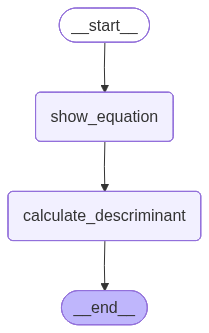

In [20]:
workflow

In [21]:
initial_state={
    'a':2,
    'b':3,
    'c':-1
}

In [22]:
result=workflow.invoke(initial_state)

In [23]:
result

{'a': 2, 'b': 3, 'c': -1, 'equation': '12x2+3x+-1', 'discreminant': 17}